In [1]:
import os
from google.colab import userdata

os.environ["ROBOFLOW_API_KEY"] = userdata.get("ROBOFLOW_API_KEY")

In [2]:
!nvidia-smi

Thu Jan 22 03:15:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   30C    P0             43W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
!pip install -q rfdetr==1.2.1 supervision==0.26.1 roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.3/266.3 kB 6.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 90.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 133.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 372.8/372.8 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
from roboflow import Roboflow
from google.colab import userdata
import os

ROBOFLOW_API_KEY = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=ROBOFLOW_API_KEY)

workspace = rf.workspace("renaire-odarve")
project = workspace.project("erotica-detection")
version = project.version(4) # version of dataset in roboflow
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to erotica-detection-4 in coco:: 100%|██████████| 15816/15816 [00:02<00:00, 6584.71it/s]


In [6]:
from rfdetr import RFDETRNano

model = RFDETRNano()

# Training parameters adjusted for A100 GPU (40GB) and YOLO-style config
model.train(
    dataset_dir=dataset.location,
    epochs=40,          # Set to 40 epochs
    batch_size=32,       # Increased for A100 40GB
    grad_accum_steps=1,  # Reduced accum steps as batch size is larger
    resolution=640       # Increased image size to 640
)

rf-detr-nano.pth: 100%|██████████| 349M/349M [00:03<00:00, 106MiB/s]


Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


reinitializing your detection head with 4 classes.


TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=4, grad_accum_steps=1, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=32, weight_decay=0.0001, epochs=40, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-nano.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[3, 6, 9, 12], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=2, dim_feedforward=2048, hidden_dim=256, sa_nheads=8, ca_nheads=

Epoch: [0]  [  0/345]  eta: 0:35:46  lr: 0.000100  class_error: 52.03  loss: 9.4720 (9.4720)  loss_ce: 0.9101 (0.9101)  loss_bbox: 1.0290 (1.0290)  loss_giou: 0.9999 (0.9999)  loss_ce_0: 0.8553 (0.8553)  loss_bbox_0: 1.2130 (1.2130)  loss_giou_0: 1.0941 (1.0941)  loss_ce_enc: 0.7923 (0.7923)  loss_bbox_enc: 1.3634 (1.3634)  loss_giou_enc: 1.2150 (1.2150)  loss_ce_unscaled: 0.9101 (0.9101)  class_error_unscaled: 52.0280 (52.0280)  loss_bbox_unscaled: 0.2058 (0.2058)  loss_giou_unscaled: 0.4999 (0.4999)  cardinality_error_unscaled: 3357.7812 (3357.7812)  loss_ce_0_unscaled: 0.8553 (0.8553)  loss_bbox_0_unscaled: 0.2426 (0.2426)  loss_giou_0_unscaled: 0.5470 (0.5470)  cardinality_error_0_unscaled: 2700.5625 (2700.5625)  loss_ce_enc_unscaled: 0.7923 (0.7923)  loss_bbox_enc_unscaled: 0.2727 (0.2727)  loss_giou_enc_unscaled: 0.6075 (0.6075)  cardinality_error_enc_unscaled: 2935.3125 (2935.3125)  time: 6.2218  data: 1.6348  max mem: 22647
Epoch: [0]  [ 10/345]  eta: 0:07:11  lr: 0.000100  cla

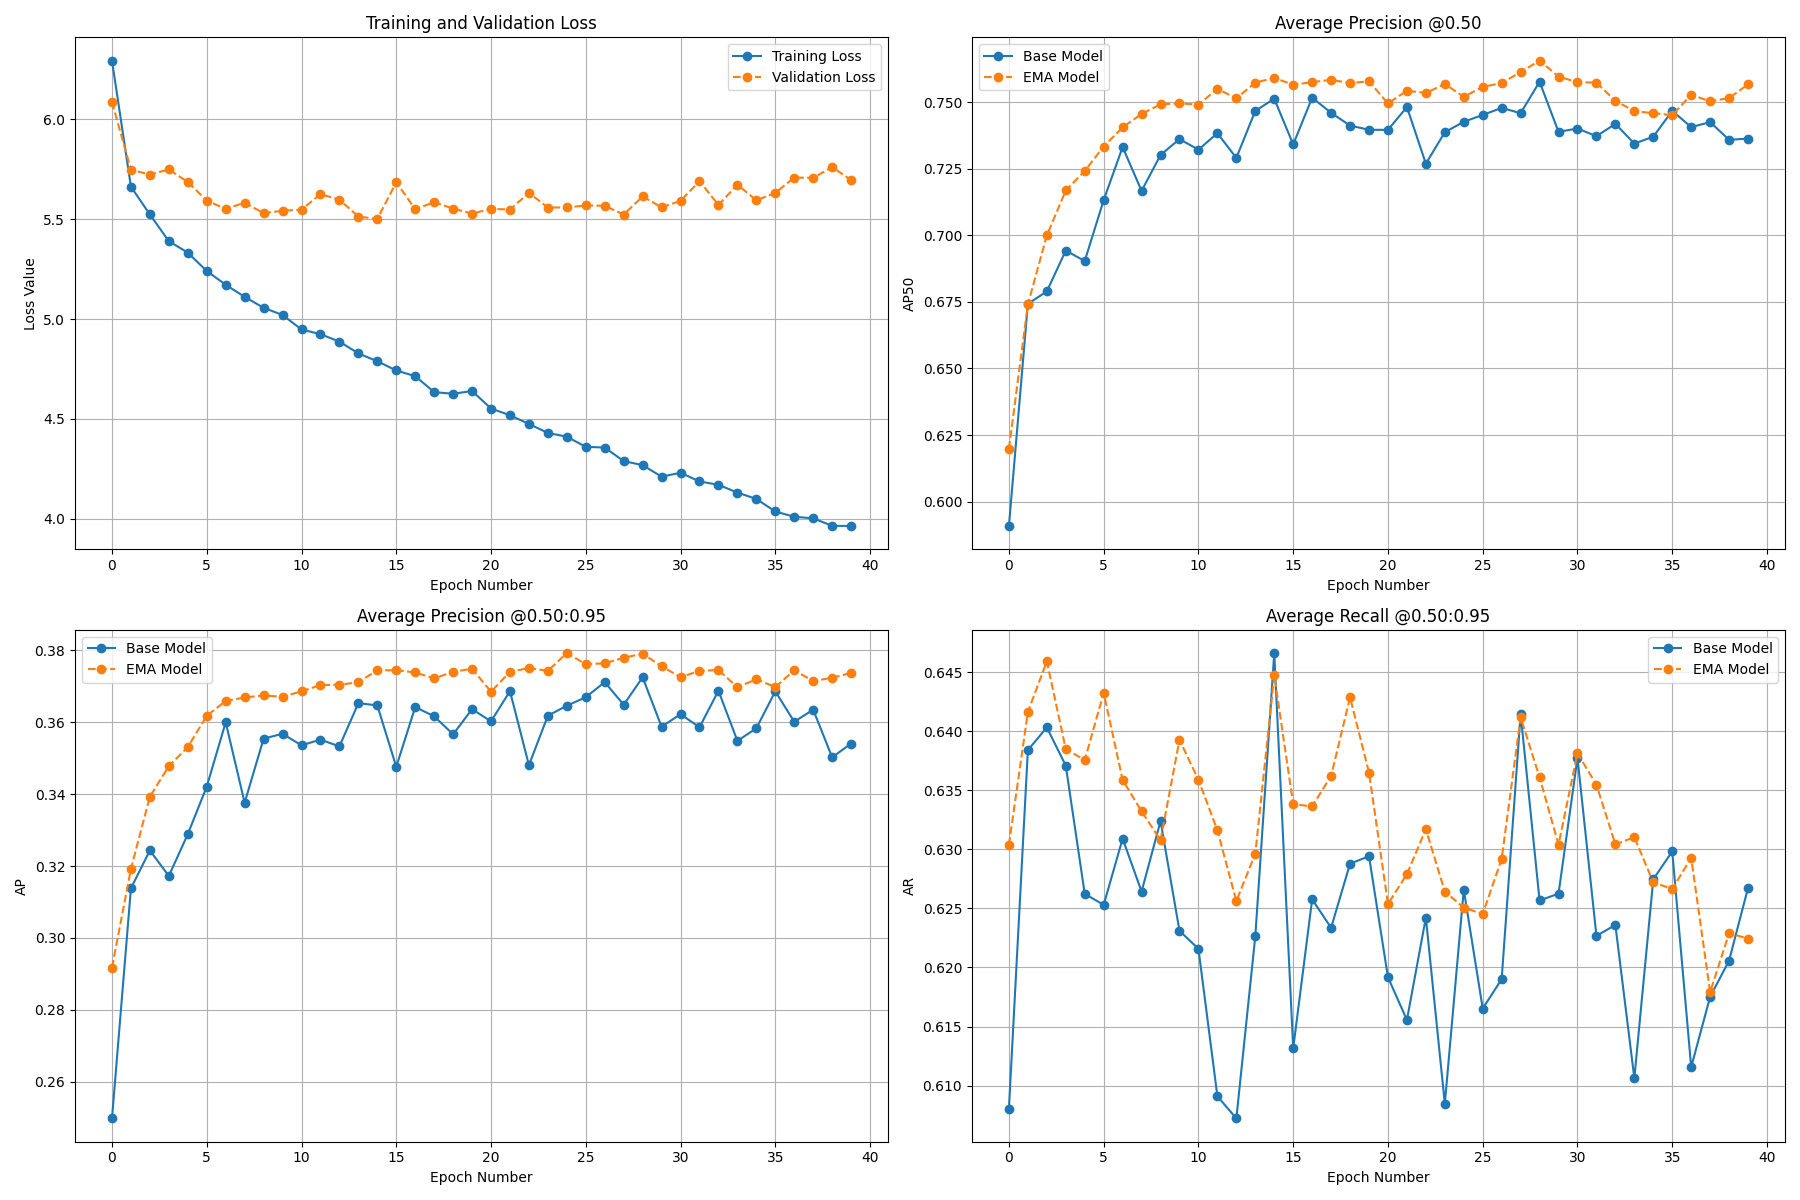

In [7]:
from PIL import Image

Image.open("/content/output/metrics_plot.png")

In [8]:
!ls -la /content/output

total 3186552
drwxr-xr-x 3 root root      4096 Jan 22 07:39 .
drwxr-xr-x 1 root root      4096 Jan 22 03:23 ..
-rw-r--r-- 1 root root 483326893 Jan 22 04:24 checkpoint0009.pth
-rw-r--r-- 1 root root 483326893 Jan 22 05:28 checkpoint0019.pth
-rw-r--r-- 1 root root 483326893 Jan 22 06:32 checkpoint0029.pth
-rw-r--r-- 1 root root 483326893 Jan 22 07:37 checkpoint0039.pth
-rw-r--r-- 1 root root 362524266 Jan 22 06:02 checkpoint_best_ema.pth
-rw-r--r-- 1 root root 362531782 Jan 22 03:41 checkpoint_best_regular.pth
-rw-r--r-- 1 root root 120811295 Jan 22 07:39 checkpoint_best_total.pth
-rw-r--r-- 1 root root 483317581 Jan 22 07:37 checkpoint.pth
drwxr-xr-x 2 root root      4096 Jan 22 03:29 eval
-rw-r--r-- 1 root root     17432 Jan 22 07:39 events.out.tfevents.1769052203.0b6d8b0dd23e.7033.0
-rw-r--r-- 1 root root    222079 Jan 22 07:39 log.txt
-rw-r--r-- 1 root root    245760 Jan 22 07:39 metrics_plot.png
-rw-r--r-- 1 root root      1160 Jan 22 07:39 results.json


In [9]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [10]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 132.86 MB | Reserved: 37992.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 132.86 MB | Reserved: 556.00 MB


In [ ]:
# Reload the best checkpoint at the SAME resolution used for training (640).
# Without this, RFDETRNano defaults to resolution=384, so every mAP number
# below would be measured at 384 on a model trained at 640 (train/inference
# mismatch that silently degrades accuracy).
model = RFDETRNano(
    pretrain_weights="/content/output/checkpoint_best_total.pth",
    resolution=640,
)
model.optimize_for_inference()

In [12]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision
from PIL import Image

# Load the dataset (Validation set)
ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/valid",
    annotations_path=f"{dataset.location}/valid/_annotations.coco.json"
)

targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    image = Image.open(path)
    # Use a low threshold for mAP calculation
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)

100%|██████████| 2416/2416 [00:42<00:00, 56.46it/s]


In [13]:
map_metric = MeanAveragePrecision()
map_result = map_metric.update(predictions, targets).compute()
print(map_result)

Average Precision (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.381
Average Precision (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.762
Average Precision (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.336
Average Precision (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.011
Average Precision (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ]                 = 0.219
Average Precision (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ]                 = 0.399


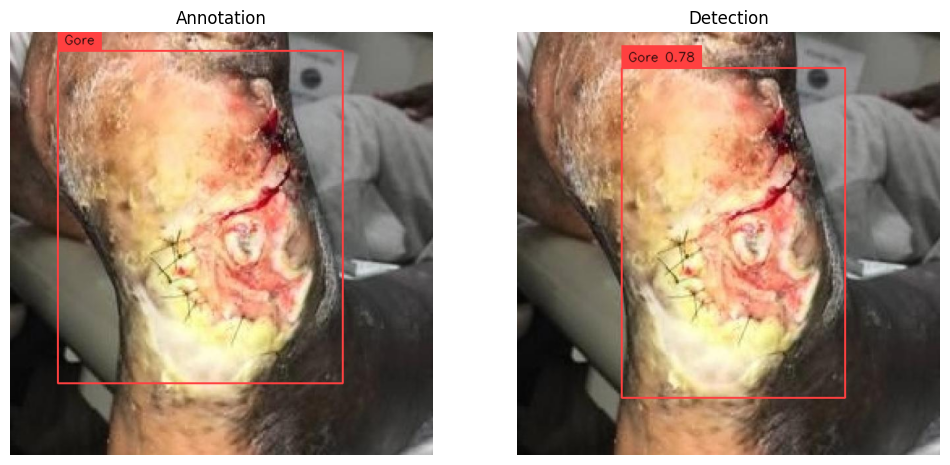

In [14]:
import supervision as sv
from PIL import Image

# Ensure ds is defined
if 'ds' not in locals():
    ds = sv.DetectionDataset.from_coco(
        images_directory_path=f"{dataset.location}/valid",
        annotations_path=f"{dataset.location}/valid/_annotations.coco.json"
    )

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
# Use default color palette
color = sv.ColorPalette.DEFAULT

bbox_annotator = sv.BoxAnnotator(color=color, thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale
)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])

In [ ]:
import os
import matplotlib.pyplot as plt
import supervision as sv

# Ensure the output directory exists
os.makedirs("/content/output", exist_ok=True)

# 1. Generate and Save Confusion Matrix
# NOTE: `predictions` were generated with threshold=0 (correct for mAP, but that
# floods a confusion matrix with near-zero-confidence false positives). Pass an
# explicit operating threshold so the CM reflects real deployment behaviour.
CM_CONF_THRESHOLD = 0.25
cm = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds.classes,
    conf_threshold=CM_CONF_THRESHOLD,
    iou_threshold=0.5,
)

cm.plot()
plt.title(f"Confusion Matrix (conf >= {CM_CONF_THRESHOLD})")
plt.tight_layout()
plt.savefig("/content/output/confusion_matrix.png")
plt.show()
print("Confusion Matrix saved to /content/output/confusion_matrix.png")

# 2. Save mAP Metrics
# We'll save the computed mAP metrics to a text file.
metrics_file = "/content/output/metrics.txt"
with open(metrics_file, "w") as f:
    f.write(str(map_result))

print(f"Metrics saved to {metrics_file}")

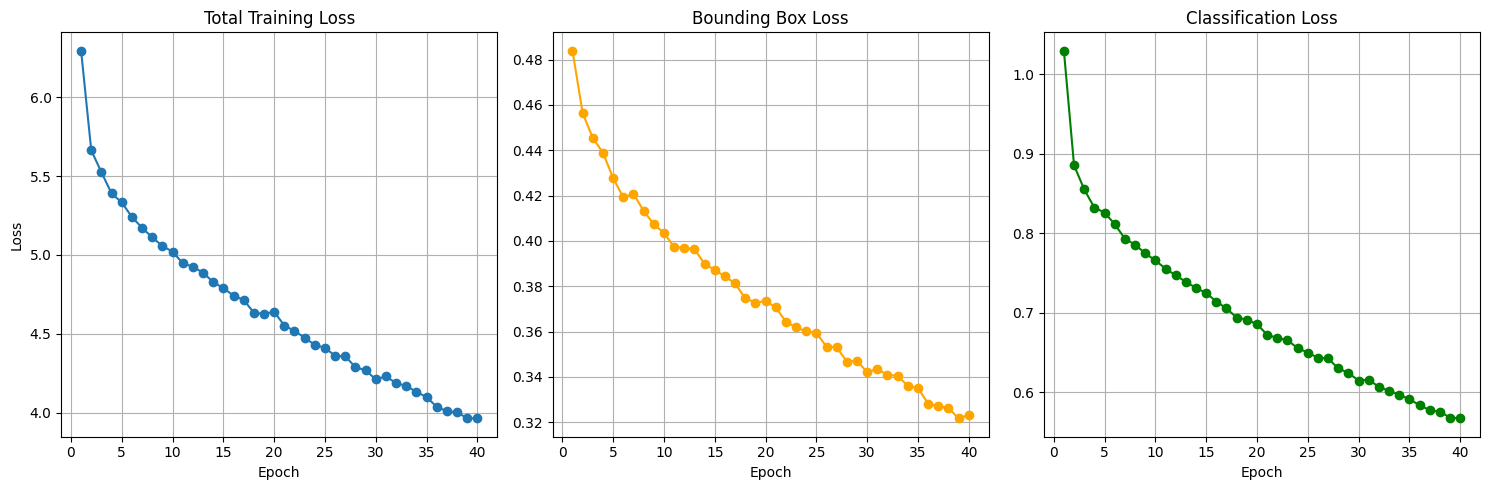

Loss curves saved to /content/output/loss_curves.png


In [18]:
import json
import matplotlib.pyplot as plt
import os

# Path to the log file generated by RF-DETR
log_path = "/content/output/log.txt"

if os.path.exists(log_path):
    epochs = []
    train_losses = []
    train_bbox_losses = []
    train_class_losses = []

    # Parse the log file
    with open(log_path, 'r') as f:
        for line in f:
            try:
                log_entry = json.loads(line)
                if 'epoch' in log_entry:
                    epochs.append(log_entry['epoch'] + 1)
                    # Updated keys to match log format (train_loss, train_loss_bbox, etc.)
                    train_losses.append(log_entry.get('train_loss', 0))
                    train_bbox_losses.append(log_entry.get('train_loss_bbox', 0))
                    train_class_losses.append(log_entry.get('train_loss_ce', 0))
            except ValueError:
                continue

    # Plotting
    if epochs:
        plt.figure(figsize=(15, 5))

        # Total Loss
        plt.subplot(1, 3, 1)
        plt.plot(epochs, train_losses, label='Total Loss', marker='o')
        plt.title('Total Training Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.grid(True)

        # BBox Loss
        plt.subplot(1, 3, 2)
        plt.plot(epochs, train_bbox_losses, label='BBox Loss', color='orange', marker='o')
        plt.title('Bounding Box Loss')
        plt.xlabel('Epoch')
        plt.grid(True)

        # Class Loss
        plt.subplot(1, 3, 3)
        plt.plot(epochs, train_class_losses, label='Class Loss', color='green', marker='o')
        plt.title('Classification Loss')
        plt.xlabel('Epoch')
        plt.grid(True)

        plt.tight_layout()
        plt.savefig("/content/output/loss_curves.png")
        plt.show()
        print("Loss curves saved to /content/output/loss_curves.png")
    else:
        print("Log file found, but no epoch data could be parsed yet.")
else:
    print(f"Could not find log file at {log_path}. Please ensure training has started and produced logs.")

In [ ]:
import time
import os
import supervision as sv
from tqdm import tqdm
from PIL import Image

# Check if map_result (validation metrics) exists from previous cells
if 'map_result' not in locals():
    print("Warning: Validation metrics (map_result) not found. Please run the validation metrics cell first.")
    val_map_str = "Not available"
else:
    val_map_str = str(map_result)

# 1. Setup Test Dataset
# We assume the test set structure mirrors the validation set
test_images_path = f"{dataset.location}/test"
test_ann_path = f"{dataset.location}/test/_annotations.coco.json"

if os.path.exists(test_images_path) and os.path.exists(test_ann_path):
    test_ds = sv.DetectionDataset.from_coco(
        images_directory_path=test_images_path,
        annotations_path=test_ann_path
    )

    # 2. Measure Inference Performance and Compute Test Metrics
    test_map_metric = sv.metrics.MeanAveragePrecision()
    test_targets = []
    test_predictions = []

    print("Running inference on Test set to measure performance and metrics...")
    start_time = time.time()

    # We iterate through the test set
    for path, image, annotations in tqdm(test_ds, desc="Processing Test Set"):
        pil_image = Image.open(path)
        # Predict - using threshold 0.01 for better mAP calculation coverage
        detections = model.predict(pil_image, threshold=0.01)

        test_targets.append(annotations)
        test_predictions.append(detections)

    end_time = time.time()

    # 3. Calculate Performance Metrics
    total_time = end_time - start_time
    num_images = len(test_ds)
    avg_latency_ms = (total_time / num_images) * 1000 if num_images > 0 else 0
    samples_per_sec = num_images / total_time if total_time > 0 else 0

    # 4. Compute Test mAP
    test_map_result = test_map_metric.update(test_predictions, test_targets).compute()

    # 5. Compile all metrics
    metrics_report = f"""
    ========================================
        RF-DETR COMPREHENSIVE METRICS
    ========================================

    --- Inference Performance (Test Set) ---
    Total Images:      {num_images}
    Total Time:        {total_time:.4f} seconds
    Avg Latency:       {avg_latency_ms:.2f} ms/image
    Throughput:        {samples_per_sec:.2f} samples/sec

    --- Validation Metrics ---
    {val_map_str}

    --- Test Metrics ---
    {test_map_result}
    ========================================
    """

    print(metrics_report)

    # 6. Save to file
    performance_file = "/content/output/comprehensive_metrics.txt"
    with open(performance_file, "w") as f:
        f.write(metrics_report)

    print(f"Comprehensive metrics saved to {performance_file}")

else:
    print(f"Test dataset not found at {test_images_path}. Skipping test metrics.")

Running inference on Test set to measure performance and metrics...


Processing Test Set:  31%|███▏      | 731/2327 [00:12<00:28, 56.97it/s]

In [ ]:
# RF-DETR ships its own ONNX exporter; just install the ONNX runtime deps it needs.
# (onnx2tf is not used here — RF-DETR's exporter traces the full detection pipeline.)
!pip install -q onnx onnxsim onnxruntime

In [ ]:
from rfdetr import RFDETRNano

checkpoint_path = "/content/output/checkpoint_best_total.pth"

# Reload the fine-tuned checkpoint at the training resolution (640) and use
# RF-DETR's built-in exporter. The previous manual route (torch.onnx /
# draft_export at 384x384) is wrong: `draft_export` does not exist in this
# torch build, the 384 dummy input mismatches the 640 training resolution, and
# hand-tracing `net.model` drops RF-DETR's postprocessing. `model.export()`
# handles all of this and writes a ready-to-run ONNX graph.
model = RFDETRNano(
    pretrain_weights=checkpoint_path,
    resolution=640,
)

model.export(output_dir="/content/output/onnx", opset_version=17)
print("ONNX export written to /content/output/onnx")